<a href="https://colab.research.google.com/github/KuldeepIsharwal/Machine-Learning-Basics/blob/main/Handling_Missing_Data_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Univariate Imputation (Numerical Data)

for normal distribution use mean
if data is skewed use median

Benifit : its simple

Disadv  : it changes distribution

          introduces automatic outliars cz many mean vals are introduced
          
          covariance changes

when to use :  when MCAR

              < 5% data is missing

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [41]:
df = pd.read_csv('/content/titanic_toy.csv')

In [42]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [43]:
df.isnull().mean()*100

,0
Age,19.865320
Fare,5.050505
Family,0.000000
Survived,0.000000


In [44]:
x = df.drop('Survived', axis=1)
y = df['Survived']


In [45]:

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [46]:
x_train.isnull().mean()

,0
Age,0.207865
Fare,0.050562
Family,0.000000


In [47]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()

In [48]:
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)
x_train['Age_median'] = x_train['Age'].fillna(median_age)

x_train['Fare_mean'] = x_train['Fare'].fillna(mean_fare)
x_train['Fare_median'] = x_train['Fare'].fillna(median_fare)

In [49]:
x_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
429,32.0,NaN,0,32.0,32.0,32.617597,14.4583
127,24.0,7.1417,0,24.0,24.0,7.141700,7.1417
271,25.0,NaN,0,25.0,25.0,32.617597,14.4583
34,28.0,82.1708,1,28.0,28.0,82.170800,82.1708
391,21.0,7.7958,0,21.0,21.0,7.795800,7.7958


<Axes: ylabel='Density'>

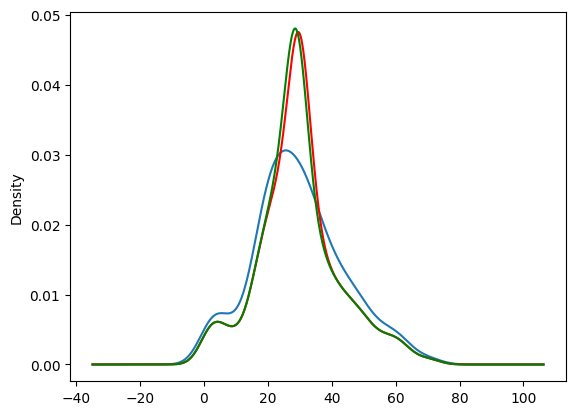

In [50]:

import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Age'].plot(kind='kde', ax=ax)
x_train['Age_mean'].plot(kind='kde', ax=ax, color='red')
x_train['Age_median'].plot(kind='kde', ax=ax, color='green')

as we can see since age had 20% missing values and when we replaced missing vals with mean/median the data became more normal

<Axes: ylabel='Density'>

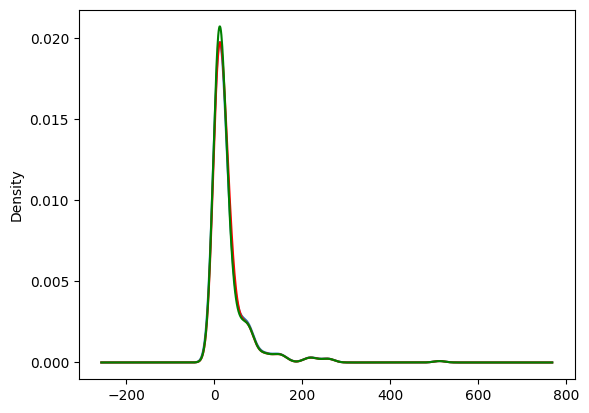

In [51]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train['Fare'].plot(kind='kde', ax=ax)
x_train['Fare_mean'].plot(kind='kde', ax=ax, color='red')
x_train['Fare_median'].plot(kind='kde', ax=ax, color='green')

here distribution is almost same cz we only had 5% vals missing

In [52]:
x_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,64.858859
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.385048,16.476305
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,51.358000
Age_median,204.349513,57.957599,-5.112563,161.812625,161.989566,55.023037,53.553455
Fare_mean,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526
Fare_median,64.858859,2448.197914,16.476305,51.358000,53.553455,2324.238526,2340.091022


<Axes: >

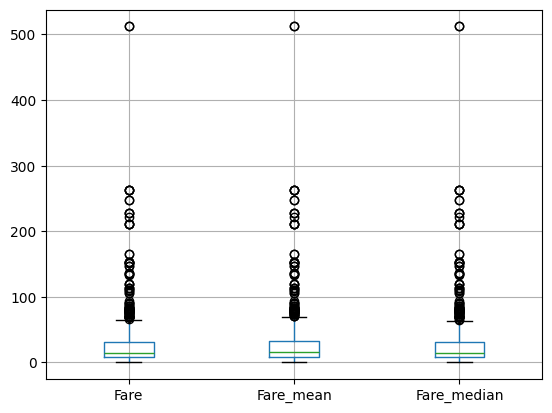

In [53]:
x_train[['Fare','Fare_mean','Fare_median']].boxplot()

#Using sklearn

In [54]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [55]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
imputer1 = SimpleImputer(strategy='mean')
imputer2 = SimpleImputer(strategy='median')

In [56]:
trf = ColumnTransformer([
    ('mean_imputer', imputer1, ['Age']),
    ('median_imputer', imputer2, ['Fare'])
],remainder='passthrough')

In [57]:
trf.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('mean_imputer', SimpleImputer(), ['Age']),
                                ('median_imputer',
                                 SimpleImputer(strategy='median'), ['Fare'])])

In [58]:
x_train =trf.transform(x_train)
x_test = trf.transform(x_test)

#Arbitrary value imputation : we fill the value with pre-determined arbitrary value

In [59]:
x_train = pd.DataFrame(x_train, columns=['Age', 'Fare', 'Family'])
x_train['new_col'] = x_train['Age'].fillna(-1)

you impute like shown above

we use it when data is not missing completely at random

# Handling Missing Categorical Data
  One way is to fill the missing values is with most frequent vals ( <5%)
  another way is to create a new category missing (when data missing is >10%)

  Easy to impliment but changes the distribution of data

In [60]:
df2 = pd.read_csv('/content/train.csv',usecols = ['GarageQual','FireplaceQu','SalePrice'])

In [61]:
df2.sample(5)

,FireplaceQu,GarageQual,SalePrice
354,Gd,TA,140000
302,TA,TA,205000
608,Gd,TA,359100
555,Gd,TA,113000
1178,Gd,Fa,154900


In [62]:
df2.isnull().mean()

,0
FireplaceQu,0.472603
GarageQual,0.055479
SalePrice,0.000000


<Axes: xlabel='GarageQual'>

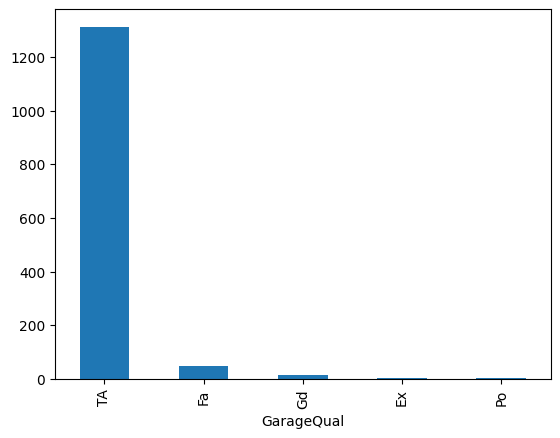

In [63]:
df2['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()

In [64]:
df2['GarageQual'].fillna('TA',inplace=True)

/tmp/ipykernel_4870/3870990513.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['GarageQual'].fillna('TA',inplace=True)


<Axes: xlabel='FireplaceQu'>

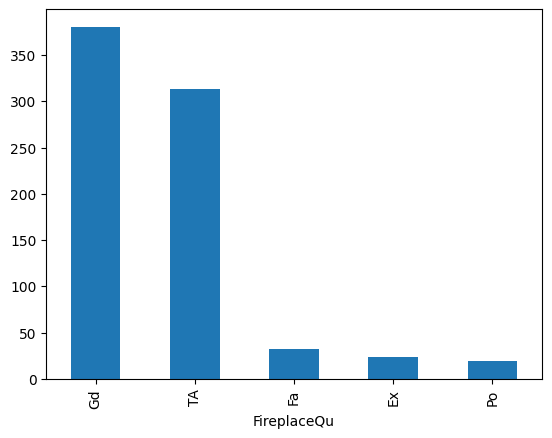

In [65]:
df2['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()

we should not fill missingvalues with Gd here because it will change the shape of distribution
cz 50% of vals are missing and top two most frequent are almost same in number but when filling with most frequent we want one category to dominate purely over others so that distribution does not have that much effect when we impute missing vals with that value

In [66]:
df2['FireplaceQu'].fillna('TA',inplace=True)

/tmp/ipykernel_4870/4026549068.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['FireplaceQu'].fillna('TA',inplace=True)


so we instead replaced it with new category missing